# Telecomabonnees Segmenteren met k-Means Clustering


## Samenvatting

Een telecomaanbieder wil zijn postpaid-abonneebestand indelen in gedragssegmenten, zodat retentieaanbiedingen gericht kunnen worden ingezet en databundels op maat kunnen worden afgestemd. Deze notebook genereert een synthetische dataset met abonneegebruik en voert vervolgens een complete k-means-segmentatiepijplijn uit in Base SAS: standaardiseer de gebruiksvariabelen met **PROC STDIZE**, kies het aantal clusters door de pseudo-F-statistiek te vergelijken over kandidaat-k's met **PROC FASTCLUS**, pas een FREQ-gewogen definitief model toe dat elke abonnee scoort, en exporteer de geleerde centroïden zodat de momentopname van volgende maand gescoord kan worden zonder opnieuw te clusteren. Het resultaat is een herbruikbare segmentatie die ruwe gebruikstelemetrie vertaalt naar een retentieplaybook.

## Gegevensbronnen

**Synthetische dataset: `WORK.SUBSCRIBERS`** (100 postpaid mobiele abonnees, inline gegenereerd met `call streaminit(20260531)`)

| Variabele | Type | Rol | Beschrijving |
|----------|------|-------------|-------------|
| `cust_id` | Char | ID | Abonnee-ID (bijv. `SUB000123`) |
| `tenure_months` | Num | Interval-invoer | Aantal maanden dat de lijn actief is (1-72) |
| `data_gb` | Num | Interval-invoer | Gemiddeld maandelijks mobiel datagebruik, in GB |
| `voice_min` | Num | Interval-invoer | Gemiddeld aantal belminuten per maand |
| `intl_min` | Num | Interval-invoer | Gemiddeld aantal internationale belminuten per maand |
| `support_calls` | Num | Interval-invoer | Klantenservicecontacten in de afgelopen 90 dagen |
| `monthly_charge` | Num | Interval-invoer | Huidige maandelijkse factuur, in dollars |
| `plan_tier` | Char | Profilering | Abonnementstype: `Basis`, `Plus` of `Onbeperkt` |
| `n_lines` | Num | FREQ-gewicht | Aantal lijnen op het account |

Drie latente gedragsprofielen zijn ingebouwd in de generator - *licht/waardebewust*, *zwaar datagebruik/streaming*, en *veelvuldig contact/risico op opzegging* - zodat de clustering echte structuur heeft om te herstellen. De interval-variabelen voeden het k-means-model; `plan_tier` wordt achtergehouden voor profilering achteraf, en `n_lines` weegt elk account naar zijn aantal lijnen. Er worden geen externe bestanden of netwerktoegang gebruikt.

## Gedragssegmentatie in vijf stappen

Mobiele providers hebben miljoenen postpaid-lijnen, en een one-size-fits-all retentiestrategie verspilt marge aan klanten die toch al zouden blijven, terwijl klanten die op het punt staan te vertrekken over het hoofd worden gezien. **Gedragssegmentatie** vertaalt ruwe gebruikstelemetrie naar een handvol bruikbare klanttypen: *licht/waardebewuste* gebruikers die prijsgevoelig zijn, *zware datagebruikers/streamers* die goede upsell-doelen zijn, en *veelvuldig-contact/risicovolle* accounts die proactieve zorg nodig hebben.

Deze notebook bouwt de segmentatie met `PROC FASTCLUS`, de k-means-procedure (disjuncte clustering) van SAS. We gaan:

1. Een synthetische maar realistische dataset met abonneegebruik genereren.
2. De gebruiksvariabelen op een gemeenschappelijke schaal zetten met **PROC STDIZE**.
3. **Het aantal clusters kiezen** door de pseudo-F-statistiek te vergelijken over kandidaat-k's.
4. Een FREQ-gewogen definitief model toepassen dat elke abonnee **scoort** en de segmenten profileert.
5. **De geleerde centroïden exporteren** zodat het model opnieuw toegepast kan worden op de momentopname van volgende maand.

## Stap 1 - Genereer een synthetisch abonneebestand

We simuleren 100 postpaid-abonnees. Elke abonnee wordt getrokken uit een van drie latente profielen met verschillende gebruikssignaturen, zodat er echte clusterstructuur is om te herstellen. We leggen de stream vast met `call streaminit` voor reproduceerbaarheid en begrenzen de gesimuleerde waarden tot plausibele bereiken met `max`/`min`/`round`.

Het nominale `plan_tier` is gecorreleerd met het latente profiel (streamers neigen naar *Onbeperkt*; waardebewuste gebruikers naar *Basis*), en `n_lines` dient later als FREQ-gewicht zodat accounts met meerdere lijnen (gezinsaccounts) proportioneel meetellen.

In [1]:
GEGEVENS subscribers;
    CALL streaminit(20260531);
    LENGTE cust_id $9 plan_tier $12;
    DOE i = 1 TOT 100;
        cust_id = cats('SUB', SCHRIJVEN(i, z6.));

        /* Drie latente gedragsprofielen, ~ongelijke prevalentie */
        u = rand('uniform');
        ALS u < 0.45 DAN profile = 1;        /* licht / waardebewust         */
        ANDERS ALS u < 0.80 DAN profile = 2;   /* zwaar datagebruik / streamer */
        ANDERS profile = 3;                    /* veelvuldig contact / risico  */

        ALS profile = 1 DAN DOE;
            tenure_months  = round(MIN(72, MAX(1, rand('normal', 30, 14))));
            data_gb        = MAX(0.2, rand('normal', 3,  1.5));
            voice_min      = MAX(0,   rand('normal', 180, 60));
            intl_min       = MAX(0,   rand('exponential') * 8);
            support_calls  = rand('poisson', 0.6);
            monthly_charge = MAX(15, rand('normal', 45, 8));
        EINDE;
        ANDERS ALS profile = 2 DAN DOE;
            tenure_months  = round(MIN(72, MAX(1, rand('normal', 40, 16))));
            data_gb        = MAX(0.2, rand('normal', 22, 6));
            voice_min      = MAX(0,   rand('normal', 320, 90));
            intl_min       = MAX(0,   rand('exponential') * 25);
            support_calls  = rand('poisson', 1.2);
            monthly_charge = MAX(15, rand('normal', 85, 12));
        EINDE;
        ANDERS DOE;
            tenure_months  = round(MIN(72, MAX(1, rand('normal', 12, 8))));
            data_gb        = MAX(0.2, rand('normal', 9,  4));
            voice_min      = MAX(0,   rand('normal', 240, 80));
            intl_min       = MAX(0,   rand('exponential') * 15);
            support_calls  = rand('poisson', 5.5);
            monthly_charge = MAX(15, rand('normal', 70, 18));
        EINDE;

        /* Abonnementstype gecorreleerd met profiel */
        p = rand('uniform');
        ALS profile = 1 DAN
            plan_tier = ifc(p < 0.70, 'Basis', ifc(p < 0.95, 'Plus', 'Onbeperkt'));
        ANDERS ALS profile = 2 DAN
            plan_tier = ifc(p < 0.65, 'Onbeperkt', ifc(p < 0.90, 'Plus', 'Basis'));
        ANDERS
            plan_tier = ifc(p < 0.45, 'Plus', ifc(p < 0.80, 'Onbeperkt', 'Basis'));

        /* Lijnen op het account: de meeste zijn single-line */
        n_lines = 1 + rand('binomial', 0.35, 3);

        /* Rond geld-/gebruikswaarden af tot realistische precisie */
        data_gb        = round(data_gb, 0.1);
        voice_min      = round(voice_min);
        intl_min       = round(intl_min);
        monthly_charge = round(monthly_charge, 0.01);

        UITVOER;
    EINDE;
    VERWIJDEREN i u p profile;
UITVOEREN;

PROCEDURE AFDRUKKEN GEGEVENS=subscribers(obs=10) noobs;
    label cust_id="Klant-ID" tenure_months="Looptijd (maanden)" data_gb="Data (GB)"
          voice_min="Belminuten" intl_min="Internationale minuten" support_calls="Supportcontacten"
          monthly_charge="Maandelijkse factuur" plan_tier="Abonnementstype" n_lines="Aantal lijnen";
    TITEL 'Steekproef van Synthetische Abonneegebruiksgegevens';
UITVOEREN;

                                  Steekproef van Synthetische Abonneegebruiksgegevens                                   

 Klant-ID  Abonnementstype  Looptijd (maanden)  Data (GB)  Belminuten  Internationale minuten  Supportcontacten  Maandelijkse factuur  Aantal lijnen
SUB000001  Basis                            15        9.7         114                       5                11                 57.07              2
SUB000002  Basis                            39        0.6         214                       2                 1                 35.88              3
SUB000003  Onbeperkt                        45       23.9         325                       6                 1                103.94              2
SUB000004  Basis                            41        1.9         202                       1                 0                 61.69              3
SUB000005  Basis                            34        2.8         112                       4                 1                 36.91


NOTE: DATA subscribers


NOTE: Wrote subscribers (100 rows, 9 columns).
NOTE: DATA elapsed:
  wall  0.04 seconds
  cpu   0.04 seconds
NOTE: PROC PRINT data=subscribers

NOTE: PROC PRINT completed: 10 observations printed, 9 variables


## Stap 2 - Zet de variabelen op een gemeenschappelijke schaal

k-means gebruikt Euclidische afstand, dus een variabele met een grote schaal zoals belminuten zou een variabele met een kleine schaal zoals supportcontacten domineren als we op de ruwe waarden zouden clusteren. De standaardoplossing is om elke interval-variabele eerst te standaardiseren tot gemiddelde 0 en standaardafwijking 1. **PROC STDIZE** met `METHOD=STD` doet precies dat en schrijft de gestandaardiseerde (z-score) kopie naar `WORK.SUBS_STD`. We nemen `cust_id`, `plan_tier` en `n_lines` ongewijzigd mee, zodat ze later beschikbaar zijn voor weging en profilering.

In [2]:
PROCEDURE stdize GEGEVENS=subscribers out=subs_std METHOD=std;
    VARIABELE tenure_months data_gb voice_min intl_min support_calls monthly_charge;
UITVOEREN;

PROCEDURE GEMIDDELDEN GEGEVENS=subs_std mean std maxdec=3;
    VARIABELE tenure_months data_gb voice_min intl_min support_calls monthly_charge;
    label tenure_months="Looptijd (maanden)" data_gb="Data (GB)" voice_min="Belminuten"
          intl_min="Internationale minuten" support_calls="Supportcontacten" monthly_charge="Maandelijkse factuur";
    TITEL 'Gestandaardiseerde Variabelen: Gemiddelde ~ 0, Std ~ 1';
UITVOEREN;

                                  Steekproef van Synthetische Abonneegebruiksgegevens                                   

                                 Gestandaardiseerde Variabelen: Gemiddelde ~ 0, Std ~ 1                                 

                                                  The MEANS Procedure

 Variable        Label                            Mean     Std Dev
 -----------------------------------------------------------------
 tenure_months   Looptijd (maanden)              0.000       1.000
 data_gb         Data (GB)                      -0.000       1.000
 voice_min       Belminuten                     -0.000       1.000
 intl_min        Internationale minuten          0.000       1.000
 support_calls   Supportcontacten               -0.000       1.000
 monthly_charge  Maandelijkse factuur            0.000       1.000
 -----------------------------------------------------------------




NOTE: PROC STDIZE data=subscribers

NOTE: PROC STDIZE: Wrote 100 rows to subs_std
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


## Stap 3 - Hoeveel segmenten? Vergelijk de pseudo-F over kandidaat-k's

In plaats van het aantal clusters te gokken, passen we FASTCLUS toe voor elke kandidaat-k en lezen we de modelfit-statistieken af die het rapporteert. De **pseudo-F-statistiek** (een verhouding tussen variantie tussen clusters en variantie binnen clusters) en de **totale R-kwadraat** belonen beide scheiding; een goede k is waar de pseudo-F hoog is en het toevoegen van nog een cluster afnemende meeropbrengst geeft. Een korte macrolus draait k = 2, 3, 4 met `MAXITER=50` en `CONVERGE=0` (itereren tot stabiliteit). Vergelijk de regels `Pseudo F Statistic` en `Overall R-Squared` in de drie onderstaande listings: de ingebouwde structuur heeft drie latente profielen, en k = 3 geeft de sterkste, meest evenwichtige oplossing.

In [3]:
%macro pick_k;
    %DOE k = 2 %TOT 4;
        PROCEDURE FASTCLUS GEGEVENS=subs_std maxclusters=&k MAXITER=50 CONVERGE=0;
            VARIABELE tenure_months data_gb voice_min intl_min support_calls monthly_charge;
            TITEL "Kandidaat Aantal Clusters: k = &k";
        UITVOEREN;
    %EINDE;
%mend pick_k;
%pick_k;

                                 Gestandaardiseerde Variabelen: Gemiddelde ~ 0, Std ~ 1                                 


                                                 The FASTCLUS Procedure                                                 
                                   Replace=FULL  Radius=0  Maxclusters=2  Maxiter=50                                    

                                                    Cluster Summary                                                     

Cluster     Frequency        RMS Std   Maximum Distance        Nearest       Centroid
                           Deviation          from Seed        Cluster       Distance
--------------------------------------------------------------------------------
1                  41         0.9639             4.8215              2         2.8826
2                  59         0.6989             4.7667              1         2.8826

                                                Statistics for Variables              


NOTE: PROC FASTCLUS data=subs_std maxclusters=2

NOTE: Using Python/scikit-learn for k-means clustering
NOTE: PROC FASTCLUS: 100 observations, 6 variables, 2 clusters using k-means
NOTE: PROC FASTCLUS data=subs_std maxclusters=3

NOTE: Using Python/scikit-learn for k-means clustering
NOTE: PROC FASTCLUS: 100 observations, 6 variables, 3 clusters using k-means
NOTE: PROC FASTCLUS data=subs_std maxclusters=4

NOTE: Using Python/scikit-learn for k-means clustering
NOTE: PROC FASTCLUS: 100 observations, 6 variables, 4 clusters using k-means


## Stap 4 - Pas de definitieve segmentatie toe en scoor elke abonnee

Met k = 3 gekozen, passen we het productiemodel toe. Deze run is volledig idiomatisch voor een operationele segmentatie:

- De `FREQ`-instructie weegt elk account naar `n_lines`, zodat een gezinsaccount met vier lijnen vier keer zoveel meetelt als een enkele lijn bij de berekening van de centroïden.
- `OUT=SCORED` schrijft elke abonnee weg met het toegewezen `CLUSTER` en de `DISTANCE` tot de centroïde van dat cluster; de `ID`-instructie neemt `cust_id` mee in die gescoorde tabel.
- `MEAN=SEG_MEANS` legt de centroïden per cluster vast (op de gestandaardiseerde schaal).
- `OUTSEED=SEG_SEEDS` slaat de definitieve centroïden op in het seed-formaat dat FASTCLUS terug kan inlezen - dit is het geëxporteerde model dat we in Stap 6 opnieuw toepassen.

De modelfit-statistieken zijn al vastgesteld in de sweep van Stap 3, dus voegen we hier de optie `SHORT` toe om de listing gefocust te houden op de clustergroottes en centroïden die de scoring-output aansturen.

In [4]:
PROCEDURE FASTCLUS GEGEVENS=subs_std maxclusters=3 MAXITER=50 CONVERGE=0 short
        out=scored mean=seg_means outseed=seg_seeds;
    VARIABELE tenure_months data_gb voice_min intl_min support_calls monthly_charge;
    FREQUENTIES n_lines;
    id cust_id;
    TITEL 'Definitieve Segmentatie: k = 3, FREQ-gewogen naar Aantal Lijnen';
UITVOEREN;

PROCEDURE AFDRUKKEN GEGEVENS=seg_means noobs;
    label tenure_months="Looptijd (maanden)" data_gb="Data (GB)" voice_min="Belminuten"
          intl_min="Internationale minuten" support_calls="Supportcontacten" monthly_charge="Maandelijkse factuur";
    TITEL 'Segmentcentroïden (Gestandaardiseerde Schaal)';
UITVOEREN;

                                 Gestandaardiseerde Variabelen: Gemiddelde ~ 0, Std ~ 1                                 


                                                 The FASTCLUS Procedure                                                 
                                   Replace=FULL  Radius=0  Maxclusters=3  Maxiter=50                                    

                                                    Cluster Summary                                                     

Cluster     Frequency        RMS Std   Maximum Distance        Nearest       Centroid
                           Deviation          from Seed        Cluster       Distance
--------------------------------------------------------------------------------
1                  51         0.5507             2.8651              2         3.1977
2                  31         0.8130             3.4539              3         3.0115
3                  18         0.8596             4.1352              2         3.0115




NOTE: PROC FASTCLUS data=subs_std maxclusters=3

NOTE: Using Python/scikit-learn for k-means clustering
NOTE: PROC FASTCLUS: 100 observations, 6 variables, 3 clusters using k-means
NOTE: PROC PRINT data=seg_means

NOTE: PROC PRINT completed: 3 observations printed, 8 variables


## Stap 5 - Profileer de segmenten in bedrijfstermen

De gescoorde tabel bevat de `CLUSTER`-toewijzing van elke abonnee, maar op de gestandaardiseerde schaal zijn de centroïden lastig te lezen. Om clusternummers om te zetten in klantprofielen koppelen we de toewijzing terug aan de oorspronkelijke `subscribers`-tabel en profileren we in echte eenheden - gigabytes, minuten en dollars. PROC MEANS vat de interval-variabelen samen per segment, en PROC FREQ kruist het achtergehouden `plan_tier` tegen het segment om de abonnementsmix van elk profiel te tonen.

                       Segmentprofielen: Gemiddeld Gebruik per Cluster (Oorspronkelijke Eenheden)                       

                                                  The MEANS Procedure

                                 Analysis Variable : tenure_months Looptijd (maanden)

                                         N
                            Segment    Obs      Mean      Std Dev      Minimum      Maximum
                            ---------------------------------------------------------------
                            1           51      33.2         14.7          1.0         61.0
                            2           31      40.5         14.0         17.0         67.0
                            3           18      12.7          7.1          1.0         30.0
                            ---------------------------------------------------------------

                                        Analysis Variable : data_gb Data (GB)

                                         N
  


NOTE: PROC SORT data=scored

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 100 rows from scored.
NOTE: Wrote scored_keys (100 rows, 11 columns).
NOTE: PROC SORT statement used.
NOTE: PROC SORT data=subscribers

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 100 rows from subscribers.
NOTE: Wrote subs_sorted (100 rows, 9 columns).
NOTE: PROC SORT statement used.
NOTE: DATA profile

NOTE: Stream 1 processed 100 rows, max BY-group size: 1 (O(1) memory verified)
NOTE: Stream 2 processed 100 rows, max BY-group size: 1 (O(1) memory verified)

NOTE: Wrote profile (100 rows, 10 columns).
NOTE: DATA elapsed:
  wall  0.02 seconds
  cpu   0.02 seconds
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.
NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_cluster_plan_tier.spec.json
NOTE: PROC FREQ statement used.


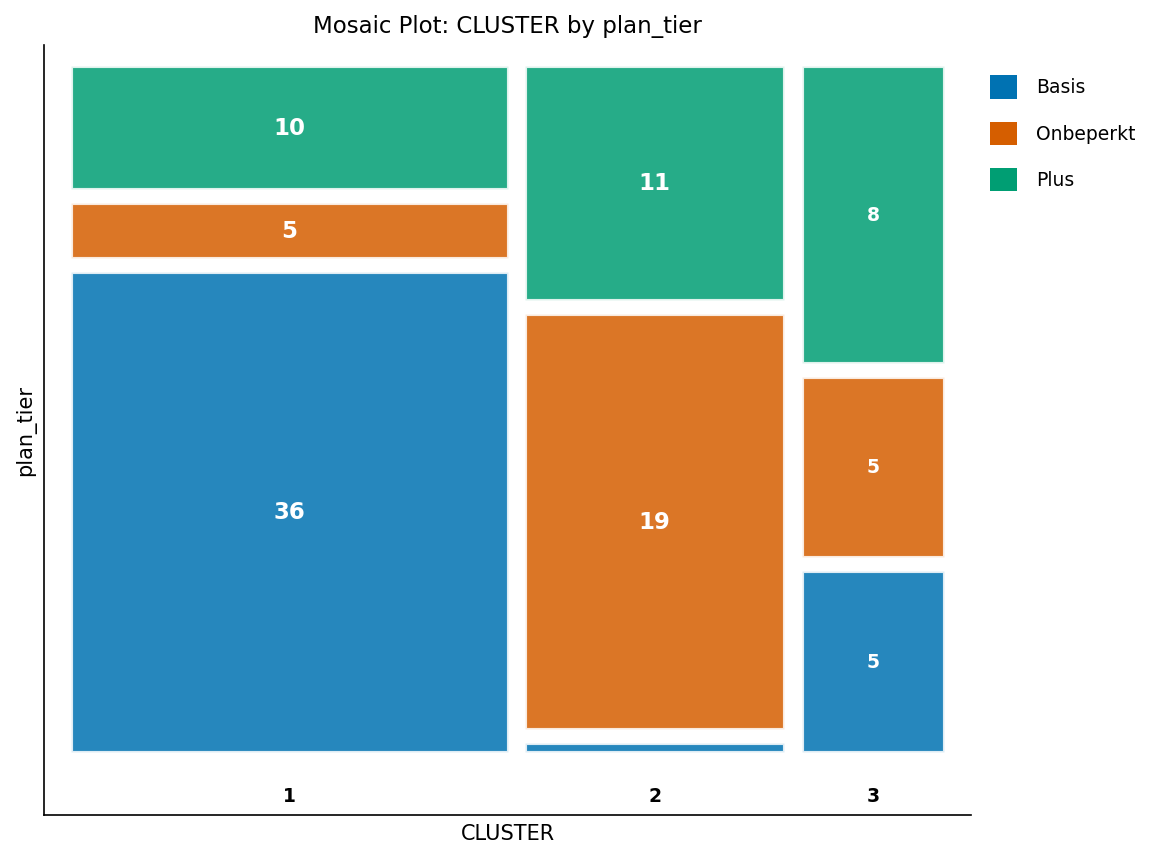

In [5]:
PROCEDURE SORTEREN GEGEVENS=scored out=scored_keys(BEWAREN=cust_id CLUSTER);
    VOLGENS cust_id;
UITVOEREN;

PROCEDURE SORTEREN GEGEVENS=subscribers out=subs_sorted;
    VOLGENS cust_id;
UITVOEREN;

GEGEVENS profile;
    SAMENVOEGEN subs_sorted(in=a) scored_keys(in=b);
    VOLGENS cust_id;
    ALS a AND b;
UITVOEREN;

PROCEDURE GEMIDDELDEN GEGEVENS=profile mean std MIN MAX maxdec=1;
    KLASSE CLUSTER;
    VARIABELE tenure_months data_gb voice_min intl_min support_calls monthly_charge;
    label CLUSTER="Segment" tenure_months="Looptijd (maanden)" data_gb="Data (GB)" voice_min="Belminuten"
          intl_min="Internationale minuten" support_calls="Supportcontacten" monthly_charge="Maandelijkse factuur";
    TITEL 'Segmentprofielen: Gemiddeld Gebruik per Cluster (Oorspronkelijke Eenheden)';
UITVOEREN;

PROCEDURE FREQUENTIES GEGEVENS=profile;
    TABLES CLUSTER * plan_tier / nocol nopercent;
    label CLUSTER="Segment" plan_tier="Abonnementstype";
    TITEL 'Abonnementsmix binnen elk Segment';
UITVOEREN;

## Stap 6 - Pas het model opnieuw toe op de momentopname van volgende maand

Een segmentatie is alleen bruikbaar als ze opnieuw toegepast kan worden zonder de hele job opnieuw te draaien. De centroïden die we in Stap 4 hebben opgeslagen in `SEG_SEEDS` vormen een draagbaar model: door ze terug te voeren als `SEED=SEG_SEEDS` met `MAXITER=0` laten we FASTCLUS elke observatie *toewijzen* aan de dichtstbijzijnde opgeslagen centroïde zonder de centroïden te verplaatsen - puur scoren, niet opnieuw fitten. Hier scoren we dezelfde gestandaardiseerde momentopname opnieuw om te bevestigen dat het geëxporteerde model de oorspronkelijke toewijzingen reproduceert; in productie zou `DATA=` verwijzen naar de gestandaardiseerde momentopname van volgende maand.

                                           Abonnementsmix binnen elk Segment                                            


                                                 The FASTCLUS Procedure                                                 
                                    Replace=FULL  Radius=0  Maxclusters=3  Maxiter=0                                    

                                                    Cluster Summary                                                     

Cluster     Frequency        RMS Std   Maximum Distance        Nearest       Centroid
                           Deviation          from Seed        Cluster       Distance
--------------------------------------------------------------------------------
1                  51         0.5507             2.8709              3         3.1175
2                  31         0.8130             3.4970              3         3.0952
3                  18         0.8596             4.2551              2         3.0952




NOTE: PROC FASTCLUS data=subs_std maxclusters=3

NOTE: Using Python/scikit-learn for k-means clustering
NOTE: PROC FASTCLUS: 100 observations, 6 variables, 3 clusters using k-means
NOTE: PROC FREQ
NOTE: ODS plot written: freq_cluster.spec.json
NOTE: PROC FREQ statement used.


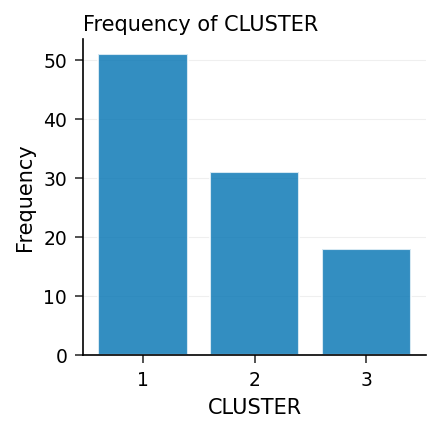

In [6]:
PROCEDURE FASTCLUS GEGEVENS=subs_std maxclusters=3 MAXITER=0 seed=seg_seeds
        out=rescored;
    VARIABELE tenure_months data_gb voice_min intl_min support_calls monthly_charge;
    id cust_id;
    TITEL 'Score een Nieuwe Momentopname met de Geëxporteerde Centroïden';
UITVOEREN;

PROCEDURE FREQUENTIES GEGEVENS=rescored;
    TABLES CLUSTER / nocum;
    label CLUSTER="Segment";
    TITEL 'Abonnees Opnieuw Gescoord via het Geëxporteerde Model';
UITVOEREN;

## Interpretatie van de resultaten

FASTCLUS heeft de drie gedragssegmenten teruggevonden die in de data zijn ingebouwd, en de profileringstabellen vertalen ze naar een retentieplaybook. Lees de segmentnummers af uit de tabel *Segmentprofielen* hierboven - de clusterlabels zijn willekeurig, dus identificeer elk profiel aan de hand van zijn gebruikssignatuur:

- **Licht/waardebewuste gebruikers** - weinig data, bescheiden facturen, langere looptijd, zeer weinig supportcontacten, meestal op *Basis*. Deze klanten zijn stabiel en prijsgevoelig; de juiste zet is *marge beschermen*, niet korten. Een passend abonnementsadvies voorkomt factuurschok zonder weggeefacties.
- **Zware datagebruikers/streamers** - veel data, veel bel- en internationale minuten, premiumfacturen, meestal *Onbeperkt*. Ze zijn loyaal en waardevol: de aanpak is *upsell en toestelupgrades*, plus proactieve communicatie over netwerkkwaliteit zodat een concurrerende actie hen niet kan wegtrekken.
- **Veelvuldig contact/risico op opzegging** - korte looptijd, verhoogd aantal supportcontacten, middenklasse-uitgaven. De frequente zorgcontacten in combinatie met korte looptijd zijn klassieke voorlopers van opzegging. Dit is het segment dat een *proactieve retentieaanbieding* verdient, gevolgd door service-herstel.